<a href="https://colab.research.google.com/github/venom312004/Transaction-Fraud-Detection/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import platform
print(platform.python_version())


3.12.12


In [2]:
!pip install -q --upgrade pip pandas keras tensorflow matplotlib numpy setuptools scikit-learn seaborn imblearn

In [3]:
import pandas as pd
import numpy as np
import keras
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, RocCurveDisplay

np.random.seed(2)

In [13]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [14]:
import os
os.listdir()

['.config', 'drive', 'creditcard.csv', 'sample_data']

In [16]:
data = pd.read_csv("creditcard.csv")


Data Exploration


In [17]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
len(data)

284807

In [19]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Defining some useful functions that will be used

In [22]:
!pip install scikeras

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scikeras.wrappers import KerasClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

skf = StratifiedKFold(n_splits = 5)
results_cv = []

In [24]:
def plot_class_distribution(df, class_column, title="Class Distribution", figsize=(6, 4), palette='Set2', count_offset=500):
    class_counts = df[class_column].value_counts()
    sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette)
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    for i, value in enumerate(class_counts.values):
        plt.text(i, value + count_offset, str(value), ha='center', va='bottom', fontsize=12)
    plt.figure(figsize=figsize)
    plt.show()

In [25]:
# Approach to plot confusion matrix (from scikit-learn.org site)
import matplotlib.pyplot as plt
import itertools

from sklearn import svm, datasets
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

In [26]:
# will keep track of the results of each model
columns = ['Model', 'Accuracy', 'FalseNegRate', 'Recall', 'Precision', 'F1 Score']
results_testset = pd.DataFrame(columns=columns)

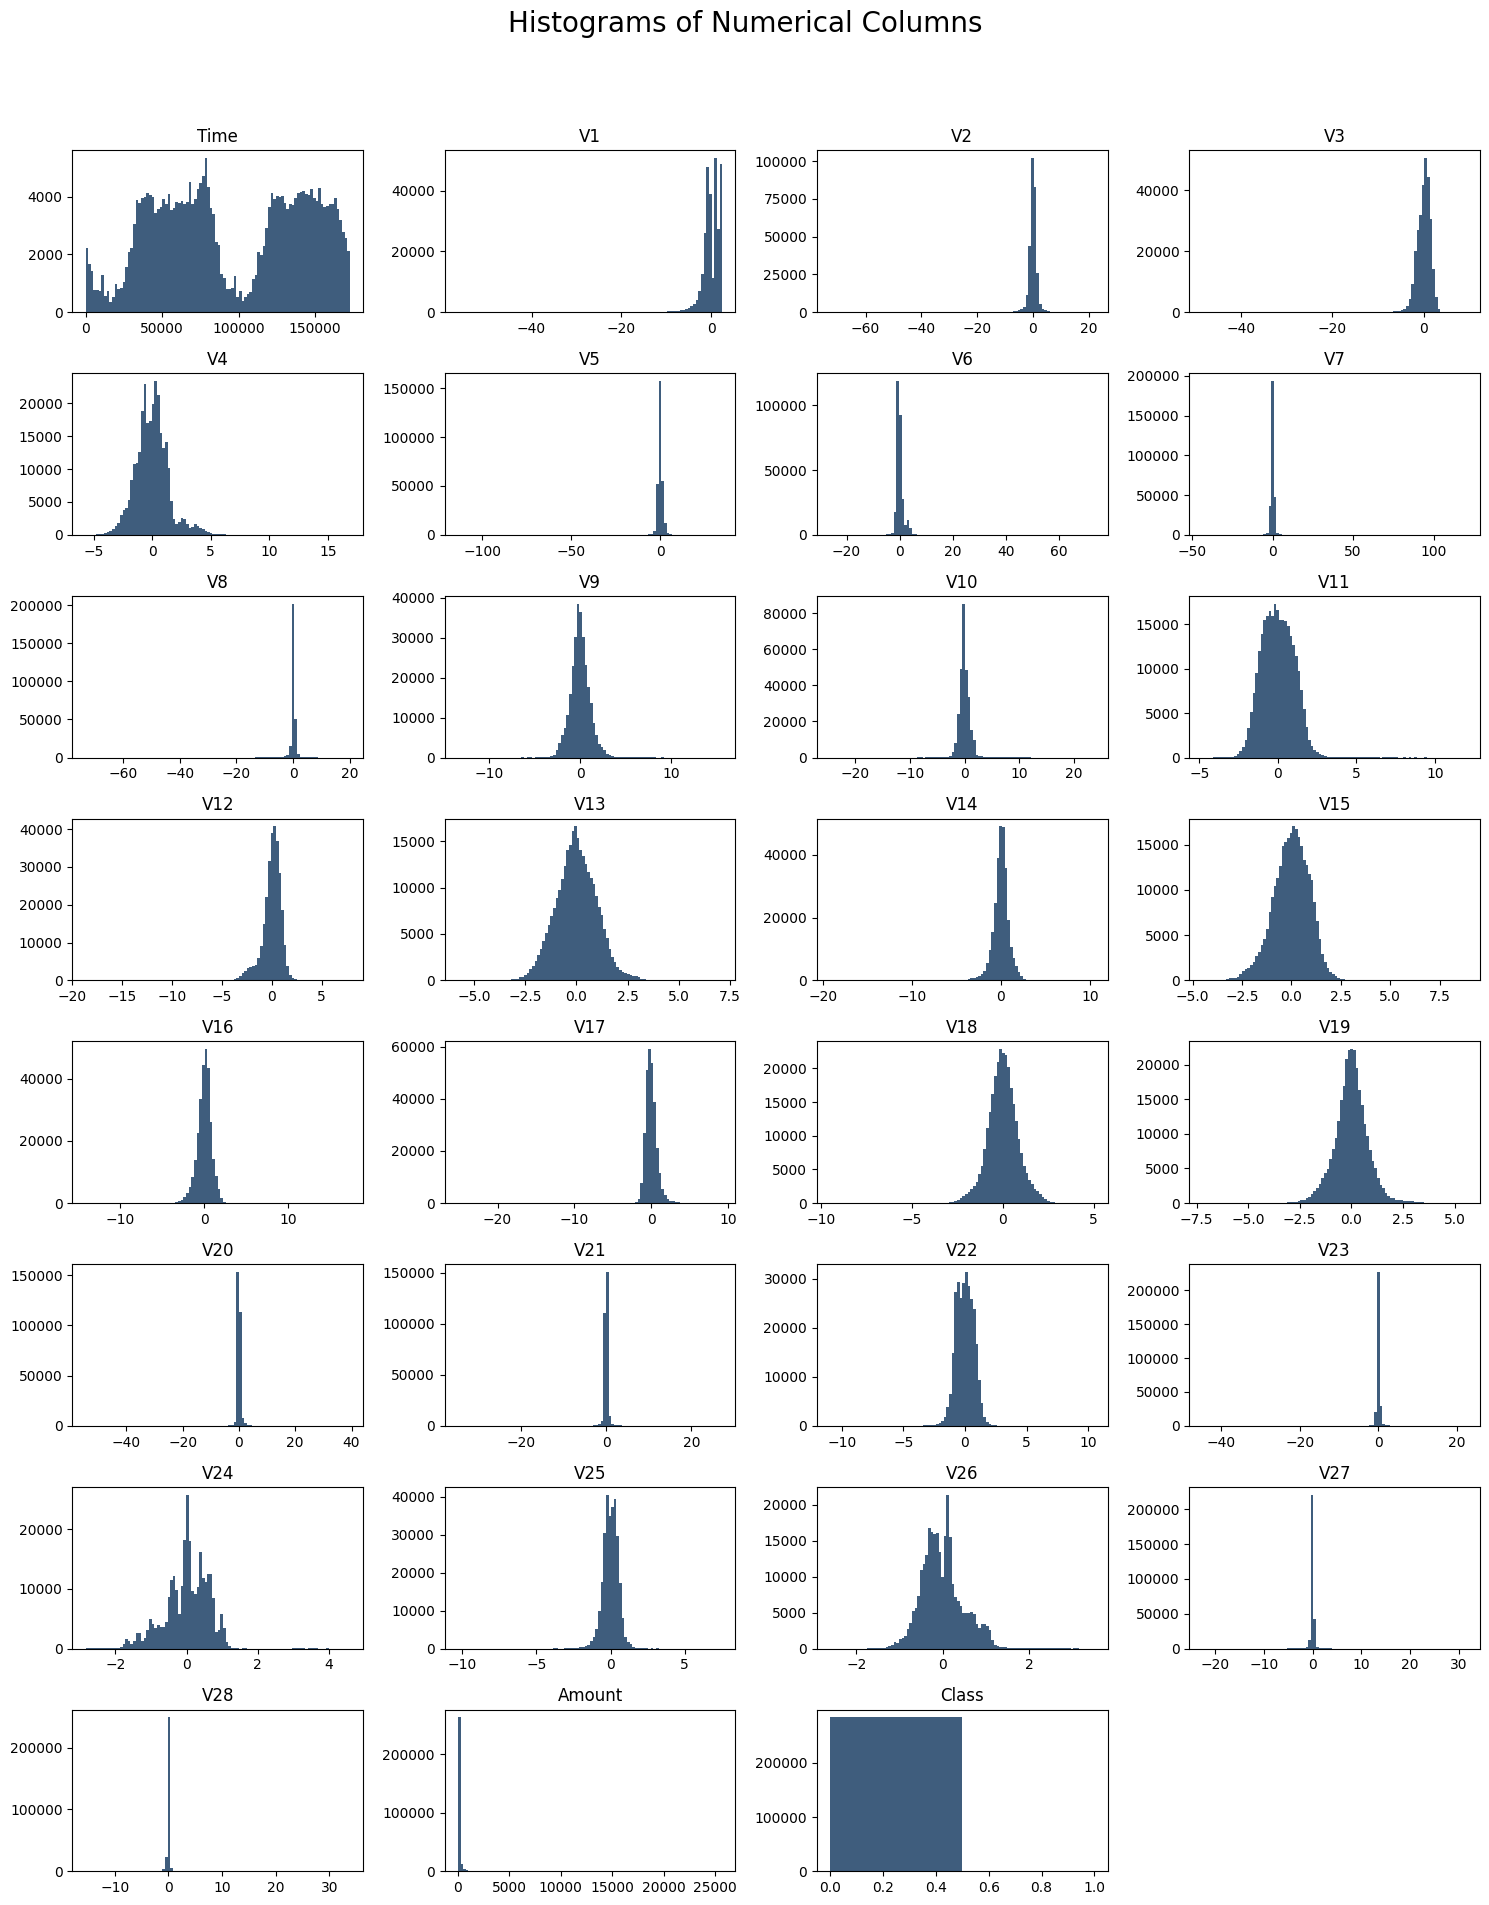

In [27]:
## Histograms
fig = plt.figure(figsize=(15, 20))
plt.suptitle('Histograms of Numerical Columns', fontsize=20)
for i in range(data.shape[1]):
    plt.subplot(8, 4, i + 1)
    f = plt.gca()
    f.set_title(data.columns.values[i])

    vals = np.size(data.iloc[:, i].unique())
    if vals >= 100:
        vals = 100                                    # limit our bins to 100 maximum

    plt.hist(data.iloc[:, i], bins=vals, color='#3F5D7D')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])



*   we can observe a large prevalence of Class 0 (non fraudulent).










In [28]:
print('Number of fraudulent transactions = %d or %d per 100,000 transactions in the dataset'
      %(len(data[data.Class==1]), len(data[data.Class==1])/len(data)*100000))

Number of fraudulent transactions = 492 or 172 per 100,000 transactions in the dataset


/tmp/ipykernel_3113/909354265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette)


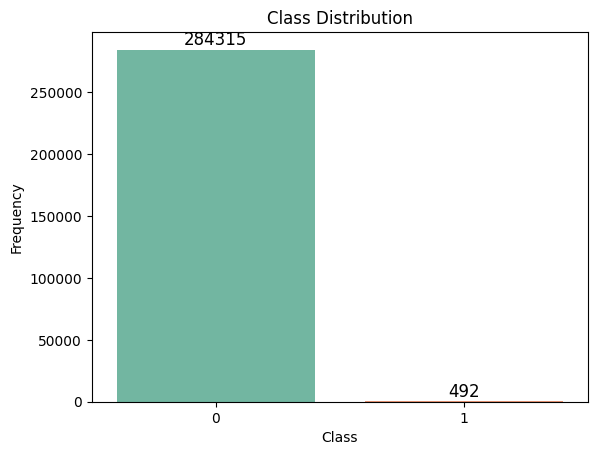

<Figure size 600x400 with 0 Axes>

In [29]:
plot_class_distribution(data, 'Class')

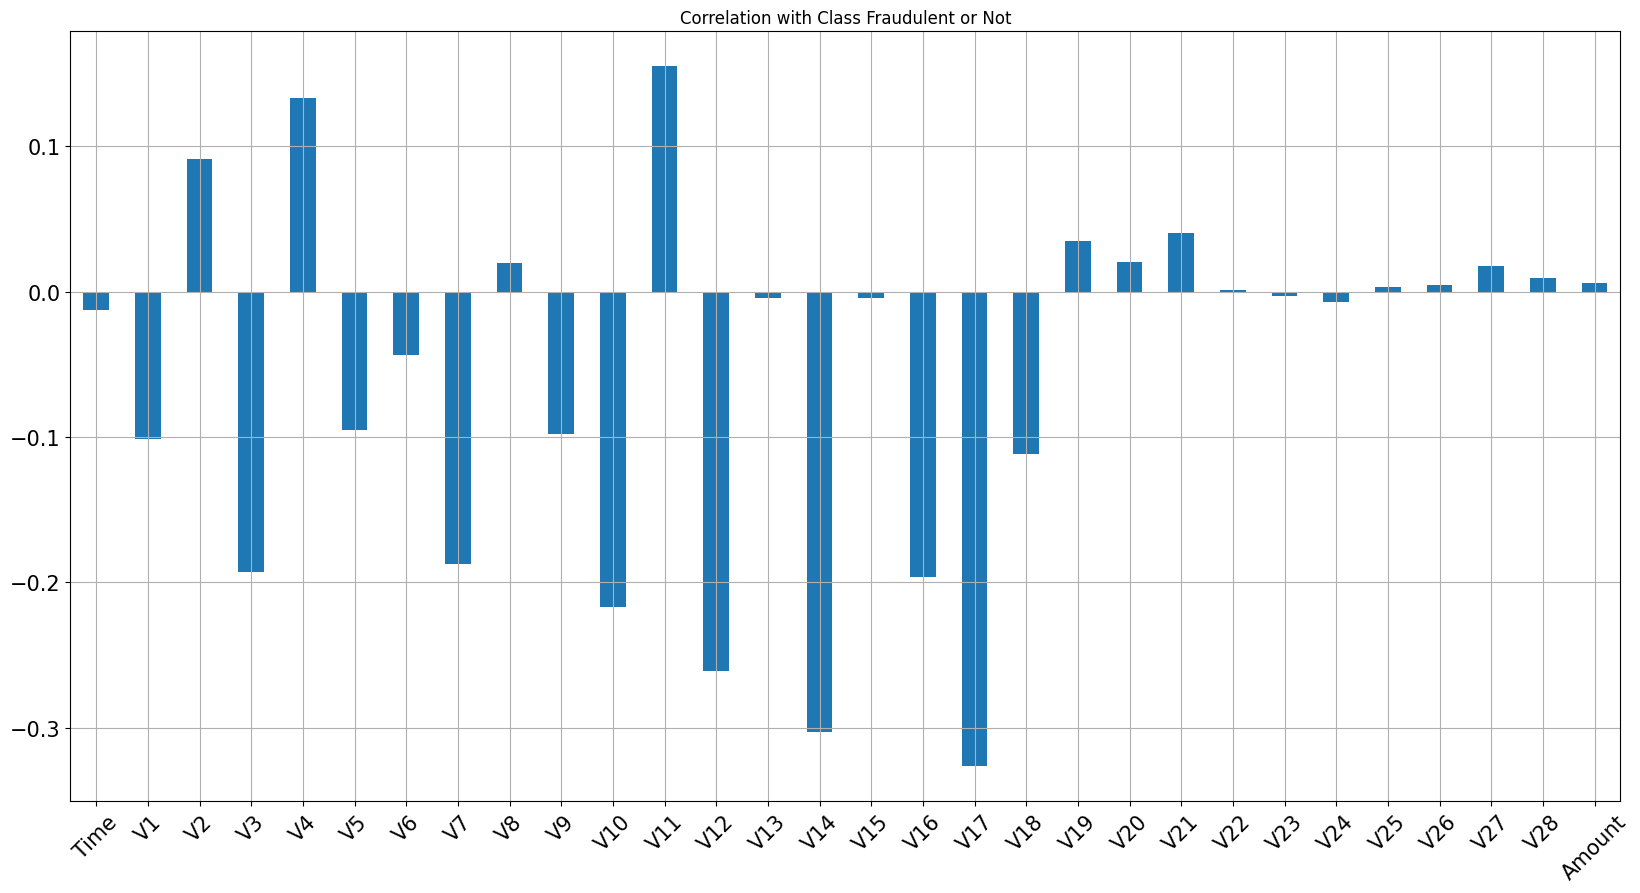

In [30]:
## Linear Correlation with Response Variable (Note: Models like RandomForest are not linear)
data2 = data.drop(columns = ['Class'])   # drop non numerical columns
data2.corrwith(data.Class).plot.bar(
        figsize = (20, 10), title = "Correlation with Class Fraudulent or Not", fontsize = 15,
        rot = 45, grid = True)
plt.show()

Pre-Processing

In [31]:
data = data.drop(['Time'],axis=1)
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [32]:
# Split the data into training and test sets first (before normalization)
X = data.iloc[:, data.columns != 'Class']
y = data.iloc[:, data.columns == 'Class']

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train_cv = X_train.copy() #create copy to use for cross validation to avoid data leakage in cv by applying processing later
y_train_cv = y_train.copy()

In [34]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [36]:
X_train['normalizedAmount'] = scaler.fit_transform(X_train['Amount'].values.reshape(-1, 1))

# Transform the test data using the same scaler (do not fit again)
X_test['normalizedAmount'] = scaler.transform(X_test['Amount'].values.reshape(-1, 1))

# Drop the original 'Amount' column from both training and test sets
X_train = X_train.drop(['Amount'], axis=1)
X_test = X_test.drop(['Amount'], axis=1)

In [37]:
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [38]:
X_train.shape

(199364, 29)

In [39]:
X_test.shape

(85443, 29)



---



# Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
random_forest = RandomForestClassifier(n_estimators=100)

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('normalize_amount', StandardScaler(), ['Amount'])
    ],
    remainder='passthrough'
)


# Construct the pipeline: preprocessing + classifier
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', random_forest)
])

# Perform cross-validation and display results
cv_scores = cross_val_score(pipeline, X_train_cv, y_train_cv.values.ravel(), cv=skf)
results_cv.append({
    "Model": "Random Forest",
    "Mean Accuracy": cv_scores.mean(),
    "Std Deviation": cv_scores.std(),
    "CV Scores": [round(score, 3) for score in cv_scores]  # Store individual scores for reference
})

In [44]:
# Pandas Series.ravel() function returns the flattened underlying data as an ndarray.
random_forest.fit(X_train,y_train.values.ravel())    # np.ravel() Return a contiguous flattened array

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
y_pred = random_forest.predict(X_test)

In [46]:
random_forest.score(X_test,y_test)

0.9994967405170698

Confusion matrix, without normalization
[[85289     7]
 [   36   111]]


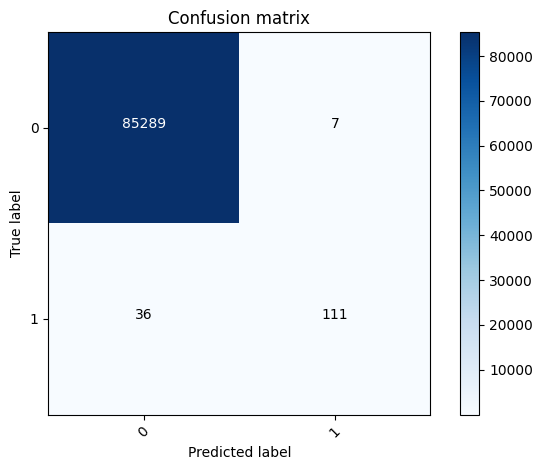

In [47]:
# Confusion matrix on the test dataset
cnf_matrix = confusion_matrix(y_test,y_pred)
plot_confusion_matrix(cnf_matrix,classes=[0,1])

In [48]:
print(results_cv)

[{'Model': 'Random Forest', 'Mean Accuracy': np.float64(0.9995385324579296), 'Std Deviation': np.float64(3.7536708382853896e-05), 'CV Scores': [np.float64(0.999), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]}, {'Model': 'Random Forest', 'Mean Accuracy': np.float64(0.9995385325837303), 'Std Deviation': np.float64(4.65152919413489e-05), 'CV Scores': [np.float64(0.999), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]}]




*  while only 6 regular transactions are wrongly predicted as fraudulent, the model only detects 78% of the fraudulent transactions. As a consequence 33 fraudulent transactions are not detected (False Negatives)
*  Let's see if we can improve this performance with other machine learning / deep learning models in the rest of the notebook



In [49]:
# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print('accuracy:%0.4f' % acc, '\tprecision:%0.4f' % prec, '\trecall:%0.4f' % rec, '\tF1-score:%0.4f' % f1)

accuracy:0.9995 	precision:0.9407 	recall:0.7551 	F1-score:0.8377


Let's store each model's performance in a dataframe for comparison purpose

In [50]:
# ### Store results in dataframe for comparing various Models
model_result = pd.DataFrame([['RandomForest', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

In [51]:
results_testset

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736


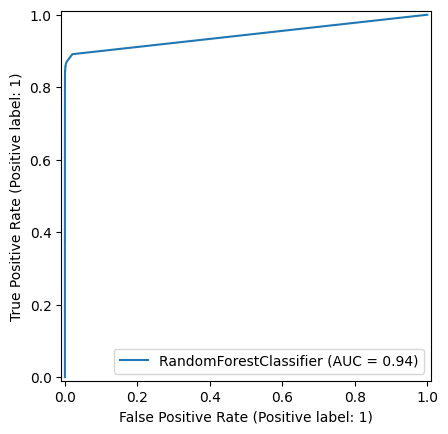

In [52]:
# Plot ROC curve
ROC_RF = RocCurveDisplay.from_estimator(random_forest, X_test, y_test)
plt.show()

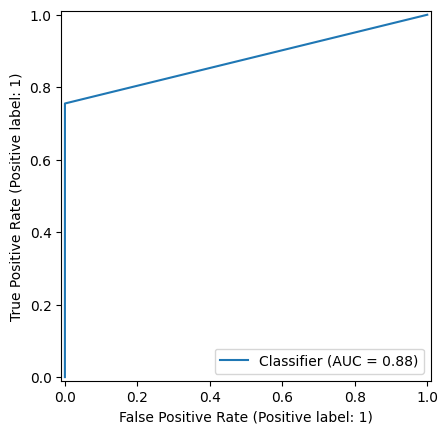

In [53]:
RocCurveDisplay.from_predictions(y_test, y_pred)



---



# Decision trees

In [54]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()

In [55]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', decision_tree)
])

In [56]:
cv_scores = cross_val_score(pipeline, X_train_cv, y_train_cv.values.ravel(), cv=skf)
results_cv.append({
    "Model": "Decision trees",
    "Mean Accuracy": cv_scores.mean(),
    "Std Deviation": cv_scores.std(),
    "CV Scores": [round(score, 3) for score in cv_scores]  # Store individual scores for reference
})

In [57]:
decision_tree.fit(X_train,y_train.values.ravel())

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [58]:
y_pred = decision_tree.predict(X_test)

In [59]:
decision_tree.score(X_test,y_test)

0.9993211848834895

Confusion matrix, without normalization
[[85272    24]
 [   34   113]]


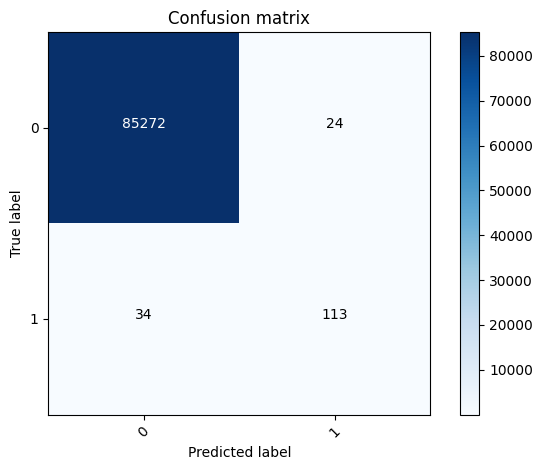

In [60]:
# Confusion matrix on the test dataset
cnf_matrix = confusion_matrix(y_test,y_pred)
plot_confusion_matrix(cnf_matrix,classes=[0,1])



*   The performance of the Decision Tree model is below the one using Random Forest. Let's check the performance indicators




In [61]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [62]:
# Create the new DataFrame with the model results
model_result = pd.DataFrame([['DecisionTree', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

In [63]:
results_testset

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736
1,DecisionTree,0.999321,0.231293,0.768707,0.824818,0.795775


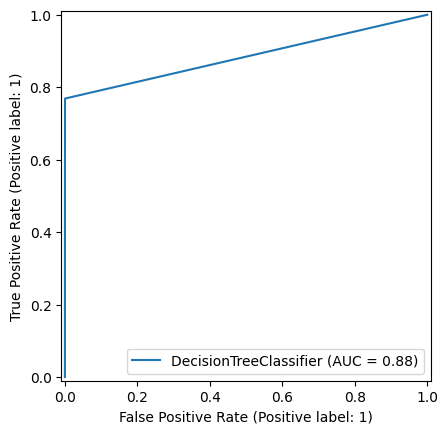

In [64]:
ROC_DT = RocCurveDisplay.from_estimator(decision_tree, X_test, y_test)
plt.show()



---



# Let's now explore Neural Network models

In [65]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Deep neural network



*   We will use a simple NN made of 5 fully-connected layers with ReLu activation. The NN takes a vector of length 29 as input. This represents the information related to each transactions, ie each line with 29 columns from the dataset. For each transaction, the final layer will output a probability distribution (sigmoid activation function) and classify either as not fraudulent (0) or fraudulent (1).
* a dropout step is included to prevent overfitting.



In [66]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [67]:
model = Sequential([
    Dense(units=16, input_dim = 29,activation='relu'),   # input of 29 columns as shown above
    Dense(units=24,activation='relu'),
    Dropout(0.5),
    Dense(24,activation='relu'),
    Dense(24,activation='relu'),
    Dense(1,activation='sigmoid'),                        # binary classification fraudulent or not
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [68]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

# Training

In [69]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [70]:
nn_classifier =  KerasClassifier(model=model, epochs=5, batch_size=15)

In [71]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', nn_classifier)
])

In [72]:
cv_scores = cross_val_score(pipeline, X_train_cv, y_train_cv, cv=skf)
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())
results_cv.append({
    "Model": "Neural Network",
    "Mean Accuracy": cv_scores.mean(),
    "Std Deviation": cv_scores.std(),
    "CV Scores": [round(score, 3) for score in cv_scores]  # Store individual scores for reference
})

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9984 - loss: 0.0106
Epoch 2/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9993 - loss: 0.0040
Epoch 3/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9993 - loss: 0.0036
Epoch 4/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9994 - loss: 0.0032
Epoch 5/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9994 - loss: 0.0032
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10633/10633 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.9984 - loss: 0.0109
Epoch 2/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9993 - loss: 0.0044
Epoch 3/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9993 - loss: 0.0042
Epoch 4/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9993 - loss: 0.0037
Epoch 5/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9993 - loss: 0.0038
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10633/10633 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.9984 - loss: 0.0109
Epoch 2/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9993 - loss: 0.0043
Epoch 3/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9994 - loss: 0.0036
Epoch 4/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9993 - loss: 0.0035
Epoch 5/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9993 - loss: 0.0034
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10633/10633 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.9984 - loss: 0.0099
Epoch 2/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9993 - loss: 0.0040
Epoch 3/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9993 - loss: 0.0039
Epoch 4/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9994 - loss: 0.0034
Epoch 5/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9994 - loss: 0.0032
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10633/10633 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.9985 - loss: 0.0104
Epoch 2/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9992 - loss: 0.0045
Epoch 3/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9993 - loss: 0.0041
Epoch 4/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9994 - loss: 0.0035
Epoch 5/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9993 - loss: 0.0036
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Cross-validation scores: [0.99897174 0.99944825 0.99944825 0.99932285 0.99934791]
Mean cross-validation score: 0.9993077990013962


In [73]:
model.fit(X_train,y_train,batch_size=15,epochs=5)

Epoch 1/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9986 - loss: 0.0094
Epoch 2/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.9993 - loss: 0.0040
Epoch 3/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9994 - loss: 0.0038
Epoch 4/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9993 - loss: 0.0037
Epoch 5/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.9994 - loss: 0.0036


In [74]:
score = model.evaluate(X_test, y_test)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9994 - loss: 0.0036


In [75]:
print(score)

[0.0036163688637316227, 0.9994382262229919]




*   The model achieves an accuracy of 99.94% ! Is this a good performance ?
*   Remember that our dataset is significantly composed of non fraudulent samples with only 172 fraudulent transactions per 100,000. Consequently, a model predicting every transaction as 'non fraudulent' would achieve 99.83% accuracy despite being unable to detect a single fraudulent case !



2671/2671 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Test Data Accuracy: 0.9994


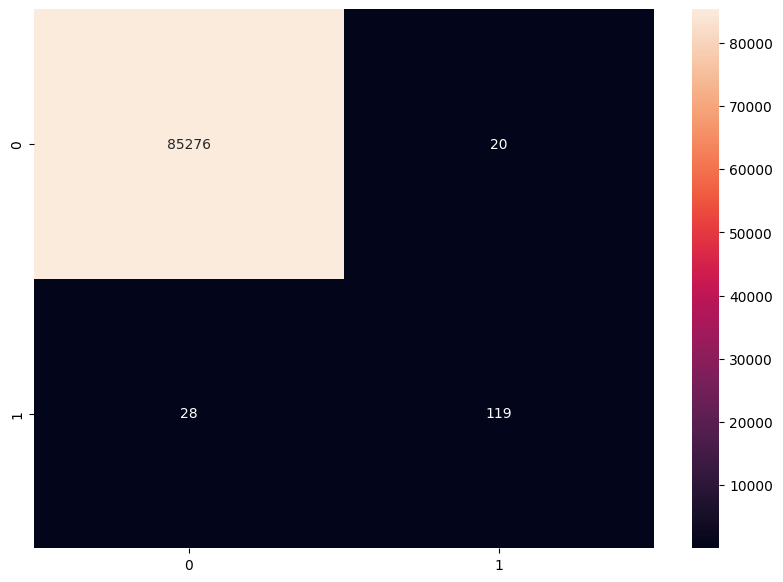

In [76]:
## Confusion Matrix on unsee test set
import seaborn as sn
y_pred = model.predict(X_test)
for i in range(len(y_test)):
    if y_pred[i]>0.5:
        y_pred[i]=1
    else:
        y_pred[i]=0
cm = confusion_matrix(y_test, y_pred) # rows = truth, cols = prediction
df_cm = pd.DataFrame(cm, index = (0, 1), columns = (0, 1))
plt.figure(figsize = (10,7))
#sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='g')
print("Test Data Accuracy: %0.4f" % accuracy_score(y_test, y_pred))

Detection of fraudulent transactions did not improve compared to the previous machine learning models.

*   115 fraudulent transactions are detected as fraudulent by the model, yet 32 fraudulent transactions are not identified (false negative) which remains an issue. Our objective must be to detect as many fraudulent transactions as possible since these can have a huge negative impact
*   21 regular transactions are detected as potentially fraudulent by the model. These are false positive. This number is negligible

Conclusion : We must find ways to further reduce the number of false negative.


In [77]:
# Alternative approach to plot confusion matrix (from scikit-learn.org site)
y_pred = model.predict(X_test)
y_test = pd.DataFrame(y_test)    # Pandas format required by confusion_matrix function

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [78]:
cnf_matrix = confusion_matrix(y_test, y_pred.round())   # y_pred.round() to convert probability to either 0 or 1 in line with y_test

In [79]:
print(cnf_matrix)

[[85276    20]
 [   28   119]]


Confusion matrix, without normalization
[[85276    20]
 [   28   119]]


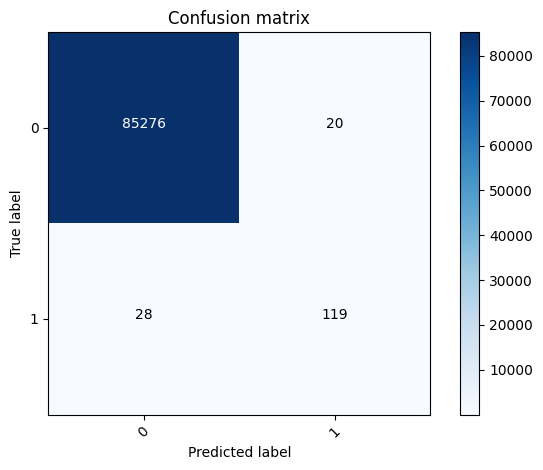

In [80]:
plot_confusion_matrix(cnf_matrix, classes=[0,1])
plt.show()

In [81]:
acc = accuracy_score(y_test, y_pred.round())
prec = precision_score(y_test, y_pred.round())
rec = recall_score(y_test, y_pred.round())
f1 = f1_score(y_test, y_pred.round())

In [82]:
# Create the new DataFrame with the model results
model_result = pd.DataFrame([['PlainNeuralNetwork', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

results_testset

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736
1,DecisionTree,0.999321,0.231293,0.768707,0.824818,0.795775
2,PlainNeuralNetwork,0.999438,0.190476,0.809524,0.856115,0.832168




---




Weighted loss to account for large class imbalance in train dataset



*  we will adjust the class imbalance by giving additional weight to the loss associated to errors made on fraudulent transaction detection. Let's review the process:




In [83]:
from sklearn.utils import class_weight
# class_weights = class_weight.compute_class_weight('balanced', np.unique(y_train), np.array([y_train[i][0] for i in range(len(y_train))]))
# class_weights = dict(enumerate(class_weights))
# class_weights
flat_y_train = np.ravel(y_train)

# Compute class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=flat_y_train
)
# Convert to dictionary format
class_weights_dict = dict(zip(np.unique(y_train), class_weights_array))
class_weights_dict

{np.int64(0): np.float64(0.500866751415694),
 np.int64(1): np.float64(288.93333333333334)}



*  The class 'Fraudulent' (y=1) is assigned a weight of 289 vs 0.5 for the class 'not fraudulent' due to the very low prevalence we detected during data exploration. This allows the model to give more importance to the errors made on fraudulent cases during training




In [84]:
fit_params = {'classifier__class_weight': class_weights_dict}

In [85]:
cv_scores = cross_val_score(pipeline, X_train_cv, y_train_cv, cv=skf,params=fit_params)
results_cv.append({
    "Model": "Weighted Neural Network",
    "Mean Accuracy": cv_scores.mean(),
    "Std Deviation": cv_scores.std(),
    "CV Scores": [round(score, 3) for score in cv_scores]  # Store individual scores for reference
})

Epoch 1/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8457 - loss: 2.0625
Epoch 2/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9413 - loss: 0.5270
Epoch 3/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9390 - loss: 0.4211
Epoch 4/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9364 - loss: 0.3798
Epoch 5/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9633 - loss: 0.2892
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Epoch 1/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.8598 - loss: 2.1569
Epoch 2/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9202 - loss: 0.5408
Epoch 3/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9311 - loss: 0.6178
Epoch 4/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9288 - loss: 0.4309
Epoch 5/5
10633/10633 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9372 - loss: 0.5570
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Epoch 1/5
1063

In [87]:
model.fit(X_train, y_train, batch_size=15, epochs=5, class_weight=class_weights_dict, shuffle=True)

Epoch 1/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 53s 4ms/step - accuracy: 0.9682 - loss: 0.2169
Epoch 2/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9645 - loss: 0.2019
Epoch 3/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9687 - loss: 0.2198
Epoch 4/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9714 - loss: 0.2869
Epoch 5/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9691 - loss: 0.2164


In [88]:
score_weighted = model.evaluate(X_test, y_test)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9765 - loss: 0.0719


In [89]:
print(score_weighted)

[0.07193834334611893, 0.9764872193336487]


2671/2671 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Test Data Accuracy: 0.9765


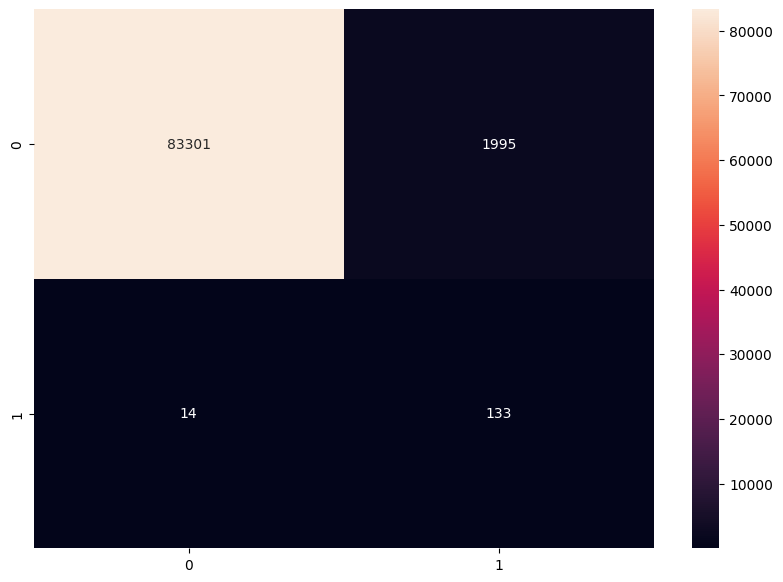

In [90]:
## Confusion Matrix on unseen test set
y_pred = model.predict(X_test)
for i in range(len(y_test)):
    if y_pred[i]>0.5:
        y_pred[i]=1
    else:
        y_pred[i]=0
cm = confusion_matrix(y_test, y_pred) # rows = truth, cols = prediction
df_cm = pd.DataFrame(cm, index = (0, 1), columns = (0, 1))
plt.figure(figsize = (10,7))
#sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='g')
print("Test Data Accuracy: %0.4f" % accuracy_score(y_test, y_pred))



*   The accuracy reduced a bit. We need to look at more detailed evaluation measures like precision and recall to gauge the true model performance
*   The model is actually much better at detecting fraudulent cases now. We have a lower False negative rate which is the key criteria for our purpose (detect a fraud when there is one).

*   But on the other hand, the model generates an excessive number of false positive compared to the previous approaches.






In [91]:
acc = accuracy_score(y_test, y_pred.round())
prec = precision_score(y_test, y_pred.round())
rec = recall_score(y_test, y_pred.round())
f1 = f1_score(y_test, y_pred.round())

In [92]:
# Create the new DataFrame with the model results
model_result = pd.DataFrame([['WeightedNeuralNetwork', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

results_testset

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736
1,DecisionTree,0.999321,0.231293,0.768707,0.824818,0.795775
2,PlainNeuralNetwork,0.999438,0.190476,0.809524,0.856115,0.832168
3,WeightedNeuralNetwork,0.976487,0.095238,0.904762,0.0625,0.116923




*  Although the recall metric improves, the F1-score collapses due to extremely poor precision. Given the very high number of transactions processed, the excessive number of false positives is clearly an issue.






---



#Undersampling



*  In order to balance the train set, another technique is undersampling. With this technique, we adjust the largest class to match the number of samples of the under-represented class. Here we want to randomly pick an amount of non-fraudulent transactions equal to the number of fraudulent transactions in the dataset.




In [93]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, RocCurveDisplay

In [94]:
fraud_indices = np.array(y[y.Class == 1].index)
number_records_fraud = len(fraud_indices)
print(number_records_fraud)

492


In [95]:
normal_indices = data[data.Class == 0].index

In [96]:
len(normal_indices)

284315

In [97]:
# Random select N indices from non fraudulent samples (N equals to number of fraudulent records)
random_normal_indices = np.random.choice(normal_indices, number_records_fraud, replace=False)
random_normal_indices = np.array(random_normal_indices)
print(len(random_normal_indices))

492


In [98]:
under_sample_indices = np.concatenate([fraud_indices,random_normal_indices])
print(len(under_sample_indices))

984


In [99]:
X_under_sample = X.iloc[under_sample_indices,:]
y_under_sample = y.iloc[under_sample_indices,:]

In [100]:
# # X_undersample = under_sample_data.iloc[:,under_sample_data.columns != 'Class']
# # y_undersample = under_sample_data.iloc[:,under_sample_data.columns == 'Class']
# X_under_sample = X.copy()
# y_under_sample = y.copy()

In [101]:
X_train_under_sampled, X_test_under_sampled, y_train_under_sampled, y_test_under_sampled = train_test_split(X_under_sample,y_under_sample, test_size=0.3)
X_train_under_sampled_cv=X_train_under_sampled.copy() # copy the undersampled training data to use for cross validation
y_train_under_sampled_cv = y_train_under_sampled.copy()

In [102]:
X_train_under_sampled['normalizedAmount'] = scaler.fit_transform(X_train_under_sampled['Amount'].values.reshape(-1, 1))
X_test_under_sampled['normalizedAmount'] = scaler.fit_transform(X_test_under_sampled['Amount'].values.reshape(-1, 1))

X_train_under_sampled = X_train_under_sampled.drop(['Amount'], axis=1)
X_test_under_sampled = X_test_under_sampled.drop(['Amount'], axis=1)

print(X_test_under_sampled.shape)
print(X_train_under_sampled.shape)

(296, 29)
(688, 29)


In [103]:
X_train_under_sampled.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,normalizedAmount
46270,0.018004,-2.253103,0.511140,0.646638,-1.336322,1.095780,-0.215027,0.374611,0.885239,-0.547968,...,0.943474,0.200068,-0.402666,-0.347025,-0.203654,-0.257221,0.896115,-0.108953,0.092235,1.792002
37580,1.248181,-0.554557,-0.099381,-0.595444,-0.534049,-0.091621,-0.612099,0.113192,-0.832359,0.238368,...,0.143561,-0.001708,-0.083955,-0.066644,-0.374736,0.394399,-0.272318,0.025025,0.027637,-0.209443
240430,-6.400057,-3.860565,-2.623060,0.450750,-0.475633,-0.618058,-0.138356,1.086189,-0.289648,-1.382198,...,-1.167175,-0.150741,-0.244925,-0.911405,0.360016,-0.422472,1.180353,-0.046541,-1.505142,0.118595
102441,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,...,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,-0.412702
252690,2.019014,0.163069,-1.589369,0.339007,0.444582,-0.646779,0.134612,-0.141482,0.114952,-0.230344,...,-0.105441,-0.292387,-0.740203,0.341887,0.689066,-0.289503,0.140196,-0.061713,-0.037181,-0.408804


In [104]:
print(X_train_under_sampled.shape)
print(X_test_under_sampled.shape)

(688, 29)
(296, 29)


/tmp/ipykernel_3113/909354265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette)


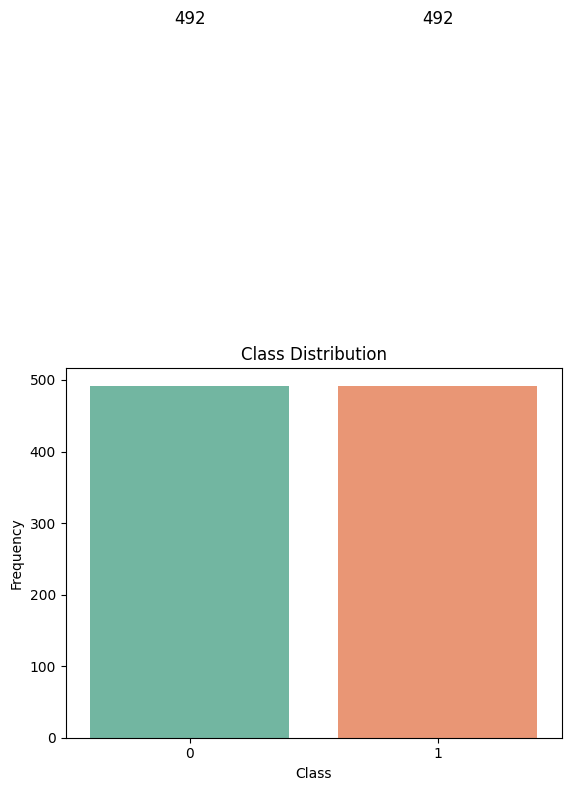

<Figure size 0x0 with 0 Axes>

In [105]:
plot_class_distribution(y_under_sample, 'Class',figsize=(0, 0))

In [106]:
X_train_under_sampled = np.array(X_train_under_sampled)
X_test_under_sampled = np.array(X_test_under_sampled)
y_train_under_sampled = np.array(y_train_under_sampled)
y_test_under_sampled = np.array(y_test_under_sampled)

In [107]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,341 (24.77 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,228 (16.52 KB)

In [108]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [109]:
cv_scores = cross_val_score(pipeline, X_train_under_sampled_cv, y_train_under_sampled_cv, cv=skf)
results_cv.append({
    "Model": "Undersampled Neural Network",
    "Mean Accuracy": cv_scores.mean(),
    "Std Deviation": cv_scores.std(),
    "CV Scores": [round(score, 3) for score in cv_scores]   # Store individual scores for reference
})

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3800 - loss: 102.6578
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4945 - loss: 16.7482
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4636 - loss: 13.9398
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4782 - loss: 10.4953
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4655 - loss: 10.6349
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4091 - loss: 108.4541
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4764 - loss: 14.0671
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4764 - loss: 14.1010
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4636 - loss: 12.0343
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4636 - loss: 12.2834
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4273 - loss: 106.0797
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4618 - loss: 14.8239
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4709 - loss: 13.8136
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4691 - loss: 11.2810
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4600 - loss: 10.4905
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4029 - loss: 113.6170
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4882 - loss: 15.3685
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4882 - loss: 9.9869 
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4501 - loss: 12.6278
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4719 - loss: 10.8560
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3938 - loss: 96.5261 
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4773 - loss: 16.0307
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4755 - loss: 13.7106
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4537 - loss: 11.7601
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4773 - loss: 10.8037
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [110]:
model.fit(X_train,y_train,batch_size=15,epochs=5)

Epoch 1/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9987 - loss: 0.0065
Epoch 2/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9992 - loss: 0.0039
Epoch 3/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9993 - loss: 0.0036
Epoch 4/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9993 - loss: 0.0035
Epoch 5/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9993 - loss: 0.0037


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Confusion matrix, without normalization
[[143   0]
 [ 32 121]]


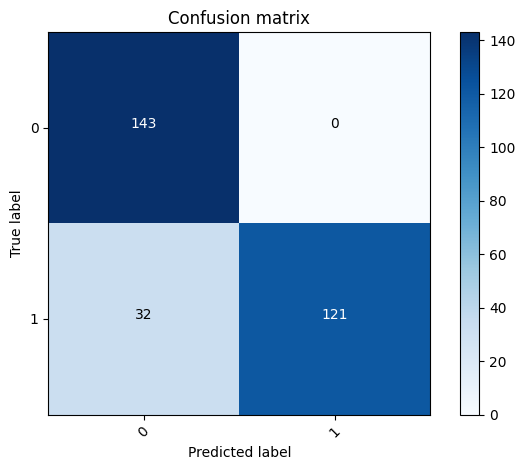

In [111]:
y_pred_under_sampled = model.predict(X_test_under_sampled)
y_expected_under_sampled = pd.DataFrame(y_test_under_sampled)
cnf_matrix = confusion_matrix(y_expected_under_sampled, y_pred_under_sampled.round())
plot_confusion_matrix(cnf_matrix, classes=[0,1])
plt.show()



*  The metrics look pretty strong on the test set....




In [112]:
acc = accuracy_score(y_test_under_sampled, y_pred_under_sampled.round())
prec = precision_score(y_test_under_sampled, y_pred_under_sampled.round())
rec = recall_score(y_test_under_sampled, y_pred_under_sampled.round())
f1 = f1_score(y_test_under_sampled, y_pred_under_sampled.round())

In [113]:
# Create the new DataFrame with the model results
model_result = pd.DataFrame([['UnderSampledNN (UnderSampled test data)', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

results_testset

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736
1,DecisionTree,0.999321,0.231293,0.768707,0.824818,0.795775
2,PlainNeuralNetwork,0.999438,0.190476,0.809524,0.856115,0.832168
3,WeightedNeuralNetwork,0.976487,0.095238,0.904762,0.0625,0.116923
4,UnderSampledNN (UnderSampled test data),0.891892,0.20915,0.79085,1.0,0.883212


....But the model fails on non fraudulent transactions as shown

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
Confusion matrix, without normalization
[[85278    18]
 [   30   117]]


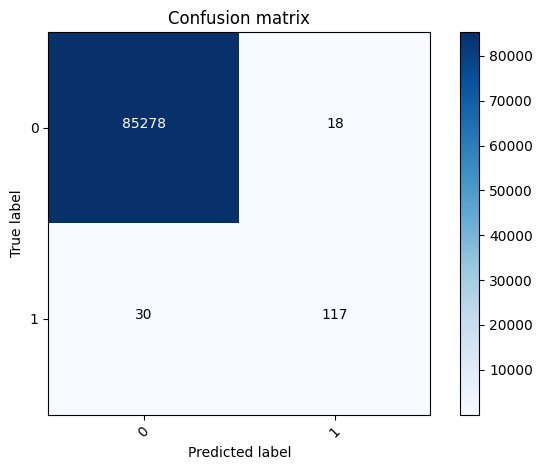

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736
1,DecisionTree,0.999321,0.231293,0.768707,0.824818,0.795775
2,PlainNeuralNetwork,0.999438,0.190476,0.809524,0.856115,0.832168
3,WeightedNeuralNetwork,0.976487,0.095238,0.904762,0.0625,0.116923
4,UnderSampledNN (UnderSampled test data),0.891892,0.20915,0.79085,1.0,0.883212
5,UnderSampledNN (Normal testing data),0.999438,0.204082,0.795918,0.866667,0.829787


In [114]:
# Confusion matrix on the original test dataset
y_pred = model.predict(X_test)
y_expected = pd.DataFrame(y_test)
cnf_matrix = confusion_matrix(y_expected, y_pred.round())
plot_confusion_matrix(cnf_matrix, classes=[0,1])
plt.show()

acc = accuracy_score(y_test, y_pred.round())
prec = precision_score(y_test, y_pred.round())
rec = recall_score(y_test, y_pred.round())
f1 = f1_score(y_test, y_pred.round())
# Create the new DataFrame with the model results
model_result = pd.DataFrame([['UnderSampledNN (Normal testing data)', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

results_testset



---



# Oversampling technique using SMOTE

(Synthetic Minority Oversample TEchnique)


*  the alternative to down-sampling is the upsampling of the minority class to the same level as the dominant one.
*  This can be achieved with the SMOTE method where a new vector is generated between 2 existing datapoints. Applying this technique allows to massively increase the number of fraudulent transactions.



In [115]:
from imblearn.over_sampling import SMOTE

In [116]:
smote = SMOTE()
X_train_resample, y_train_resample = smote.fit_resample(X_train, y_train)
X_test_resample, y_test_resample = smote.fit_resample(X_test, y_test)

In [117]:
print('Number of total transactions before SMOTE upsampling: ', len(y), '...after SMOTE upsampling: ', len(y_train_resample)+len(y_test_resample))
print('Number of fraudulent transactions before SMOTE upsampling: ', len(y[y.Class==1]),
      '...after SMOTE upsampling: ', np.sum(y_test_resample[y_test_resample==1]) + np.sum(y_train_resample[y_train_resample==1]))

Number of total transactions before SMOTE upsampling:  284807 ...after SMOTE upsampling:  568630
Number of fraudulent transactions before SMOTE upsampling:  492 ...after SMOTE upsampling:  284315.0


In [118]:

X_train_resample = pd.DataFrame(X_train_resample)
X_test_resample = pd.DataFrame(X_test_resample)
y_train_resample = pd.DataFrame(y_train_resample)
y_test_resample = pd.DataFrame(y_test_resample)
y_resample= pd.DataFrame(np.concatenate([y_train_resample,y_test_resample]))

In [119]:
y_resample.rename(columns={0: 'Class'}, inplace=True)

/tmp/ipykernel_3113/909354265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette)


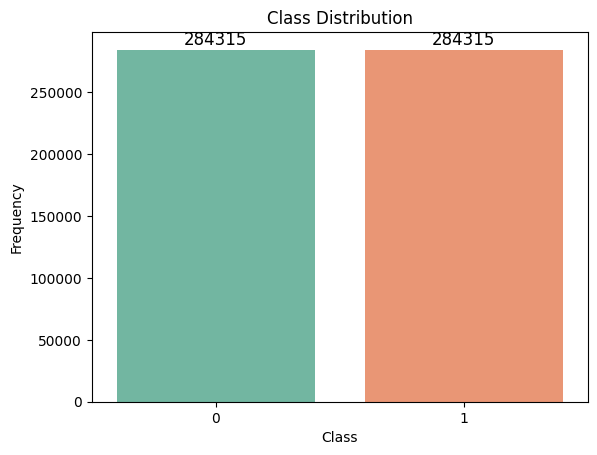

<Figure size 100x100 with 0 Axes>

In [120]:
plot_class_distribution(y_resample, 'Class', figsize=(1, 1))

In [121]:
X_train_resample = np.array(X_train_resample)
X_test_resample = np.array(X_test_resample)
y_train_resample = np.array(y_train_resample)
y_test_resample = np.array(y_test_resample)

In [122]:
model = Sequential([
    Dense(units=16, input_dim = 29,activation='relu'),   # input of 29 columns as shown above
    Dense(units=24,activation='relu'),
    Dropout(0.5),
    Dense(24,activation='relu'),
    Dense(24,activation='relu'),
    Dense(1,activation='sigmoid'),                        # binary classification fraudulent or not
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [124]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [125]:
from imblearn.pipeline import Pipeline as ImbPipeline
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', nn_classifier)
])

In [126]:
cv_scores = cross_val_score(pipeline, X_train_cv, y_train_cv, cv=skf)
results_cv.append({
    "Model": "OverSampled Neural Network",
    "Mean Accuracy": cv_scores.mean(),
    "Std Deviation": cv_scores.std(),
    "CV Scores": [round(score, 3) for score in cv_scores]  # Store individual scores for reference
})

Epoch 1/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.9442 - loss: 0.2501
Epoch 2/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 54s 3ms/step - accuracy: 0.9788 - loss: 0.0560
Epoch 3/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.9850 - loss: 0.0424
Epoch 4/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.9884 - loss: 0.0354
Epoch 5/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 54s 3ms/step - accuracy: 0.9900 - loss: 0.0313
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Epoch 1/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.9329 - loss: 0.2936
Epoch 2/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.9699 - loss: 0.0736
Epoch 3/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - accuracy: 0.9789 - loss: 0.0573
Epoch 4/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 81s 2ms/step - accuracy: 0.9832 - loss: 0.0485
Epoch 5/5
21229/21229 ━━━━━━━━━━━━━━━━━━━━ 54s 3ms/step - accuracy: 0.9861 - loss: 0.0420
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Epoch 1/5
2122

In [127]:
model.fit(X_train_resample,y_train_resample,batch_size=15,epochs=5)

Epoch 1/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 85s 3ms/step - accuracy: 0.9885 - loss: 0.0339
Epoch 2/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step - accuracy: 0.9969 - loss: 0.0126
Epoch 3/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - accuracy: 0.9976 - loss: 0.0099
Epoch 4/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 0.9980 - loss: 0.0084
Epoch 5/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - accuracy: 0.9983 - loss: 0.0077


5331/5331 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Confusion matrix, without normalization
[[85129   167]
 [12132 73164]]


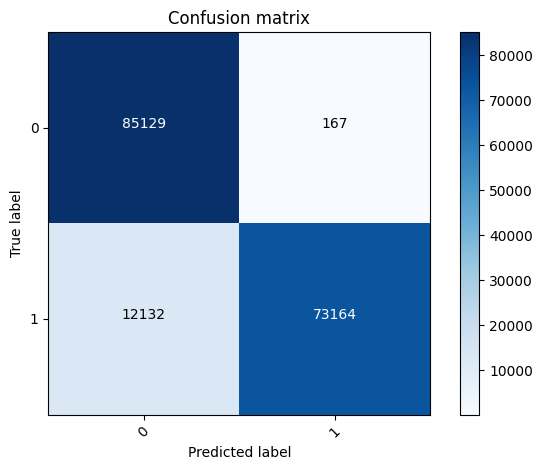

In [128]:
y_pred_oversampling = model.predict(X_test_resample)
y_expected_oversampling = pd.DataFrame(y_test_resample)
cnf_matrix = confusion_matrix(y_expected_oversampling, y_pred_oversampling.round())
plot_confusion_matrix(cnf_matrix, classes=[0,1])
plt.show()



*   Notice the absence of False Negatives. The model is able to detect all fraudulent transactions on the unseen test set.




In [129]:
acc = accuracy_score(y_test_resample, y_pred_oversampling.round())
prec = precision_score(y_test_resample, y_pred_oversampling.round())
rec = recall_score(y_test_resample, y_pred_oversampling.round())
f1 = f1_score(y_test_resample, y_pred_oversampling.round())

In [130]:
# Create the new DataFrame with the model results
model_result = pd.DataFrame([['OverSampledNN (OverSampled testing data)', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

results_testset

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736
1,DecisionTree,0.999321,0.231293,0.768707,0.824818,0.795775
2,PlainNeuralNetwork,0.999438,0.190476,0.809524,0.856115,0.832168
3,WeightedNeuralNetwork,0.976487,0.095238,0.904762,0.0625,0.116923
4,UnderSampledNN (UnderSampled test data),0.891892,0.20915,0.79085,1.0,0.883212
5,UnderSampledNN (Normal testing data),0.999438,0.204082,0.795918,0.866667,0.829787
6,OverSampledNN (OverSampled testing data),0.927904,0.142234,0.857766,0.997723,0.922466




*  All metrics are excellent for this last model


2671/2671 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Confusion matrix, without normalization
[[85129   167]
 [   25   122]]


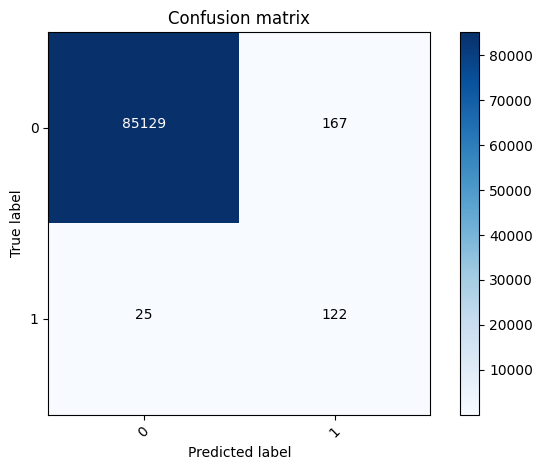

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736
1,DecisionTree,0.999321,0.231293,0.768707,0.824818,0.795775
2,PlainNeuralNetwork,0.999438,0.190476,0.809524,0.856115,0.832168
3,WeightedNeuralNetwork,0.976487,0.095238,0.904762,0.0625,0.116923
4,UnderSampledNN (UnderSampled test data),0.891892,0.20915,0.79085,1.0,0.883212
5,UnderSampledNN (Normal testing data),0.999438,0.204082,0.795918,0.866667,0.829787
6,OverSampledNN (OverSampled testing data),0.927904,0.142234,0.857766,0.997723,0.922466
7,OverSampledNN (Normal testing data),0.997753,0.170068,0.829932,0.422145,0.559633


In [131]:
# Confusion matrix on the whole dataset
y_pred = model.predict(X_test)
y_expected = pd.DataFrame(y_test)
cnf_matrix = confusion_matrix(y_expected, y_pred.round())
plot_confusion_matrix(cnf_matrix, classes=[0,1])
plt.show()

acc = accuracy_score(y_test, y_pred.round())
prec = precision_score(y_test, y_pred.round())
rec = recall_score(y_test, y_pred.round())
f1 = f1_score(y_test, y_pred.round())

# Create the new DataFrame with the model results
model_result = pd.DataFrame([['OverSampledNN (Normal testing data)', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

results_testset



*  Notice the absence of False Negatives. The model is able to detect all fraudulent transactions on the full dataset
*  Notice the limited number of False Positives which means a lot less verification work (on legitimate transactions) for the fraud departement.



# GAMs

In [135]:
!pip install pygam

In [136]:
from pygam import LogisticGAM,s,l
gam = LogisticGAM(s(0)+s(1)+s(2) + s(3)+ s(4)+ s(5)+ s(6)+ s(7)
                  + s(8)+ l(9)+ s(10)+ l(11)+ s(12)+ l(13)+ s(14)
                  + s(15)+ s(16)+ l(17)+ s(18)+ s(19)+ s(20)+ s(21)+ s(22)
                  + s(23)+ s(24)+ s(25)+ s(26)+ s(27)+ s(28))

In [137]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gam)
])

In [138]:
cv_scores = cross_val_score(pipeline, X_train_cv, y_train_cv, cv=skf)
results_cv.append({
    "Model": "Gam with spline + linear",
    "Mean Accuracy": cv_scores.mean(),
    "Std Deviation": cv_scores.std(),
    "CV Scores": [round(score, 3) for score in cv_scores]  # Store individual scores for reference
})

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py", line 275, in get_tags
    tags = estimator.__sklearn_tags__()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pygam/terms.py", line 494, in __getattr__
    return self._super_get(name)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pygam/terms.py", line 416, in _super_get
    return super(MetaTermMixin, self).__getattribute__(name)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'LogisticGAM' object has no attribute '__sklearn_tags__'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packa

In [139]:
gam.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/pygam/links.py:137: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/usr/local/lib/python3.12/dist-packages/pygam/pygam.py:631: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2


LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + l(9) + s(10) + l(11) + s(12) + l(13) + s(14) + s(15) + s(16) + l(17) + s(18) + s(19) + s(20) + s(21) + s(22) + s(23) + s(24) + s(25) + s(26) + s(27) + s(28) + intercept,
   tol=0.0001, verbose=False)

In [140]:
gam.accuracy(X_test, y_test)

np.float64(0.9995084442259752)

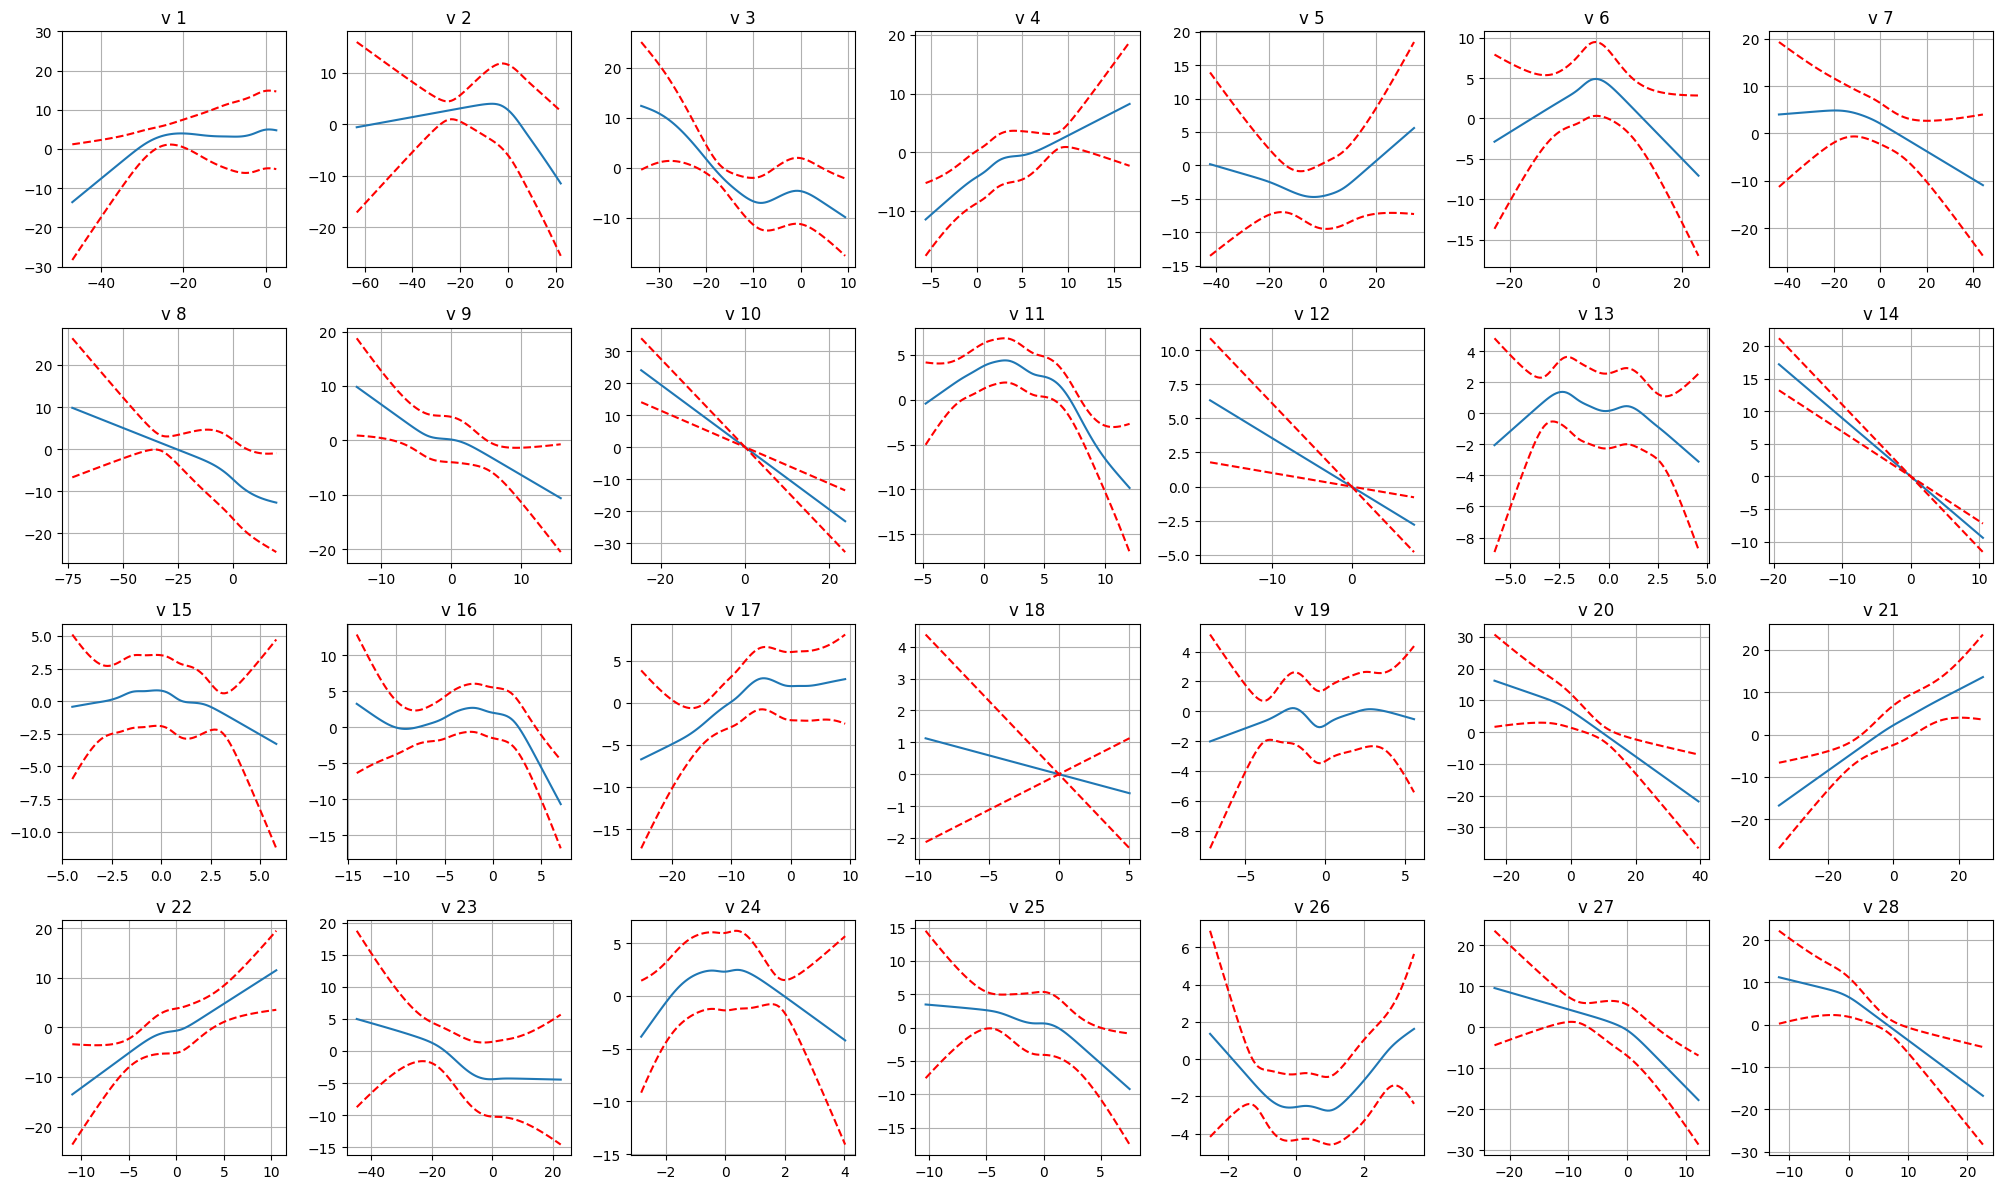

In [141]:
fig, axs = plt.subplots(4, 7, figsize=(20, 12))

for i, ax in enumerate(axs.flat):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    if i == 0:
        ax.set_ylim(-30,30)
    ax.set_title(f'v {i+1}')
    ax.grid()


plt.tight_layout()
plt.show()

In [142]:
gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     83.5267
Link Function:                        LogitLink Log Likelihood:                                  -455.7143
Number of Samples:                       199364 AIC:                                             1078.4818
                                                AICc:                                            1078.5544
                                                UBRE:                                               2.0057
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.8205
Feature Function                  Lam

/tmp/ipykernel_3113/3358381670.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


Confusion matrix, without normalization
[[85289     7]
 [   35   112]]


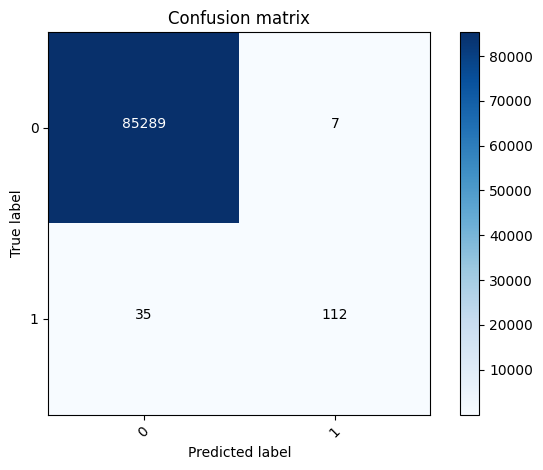

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736
1,DecisionTree,0.999321,0.231293,0.768707,0.824818,0.795775
2,PlainNeuralNetwork,0.999438,0.190476,0.809524,0.856115,0.832168
3,WeightedNeuralNetwork,0.976487,0.095238,0.904762,0.0625,0.116923
4,UnderSampledNN (UnderSampled test data),0.891892,0.20915,0.79085,1.0,0.883212
5,UnderSampledNN (Normal testing data),0.999438,0.204082,0.795918,0.866667,0.829787
6,OverSampledNN (OverSampled testing data),0.927904,0.142234,0.857766,0.997723,0.922466
7,OverSampledNN (Normal testing data),0.997753,0.170068,0.829932,0.422145,0.559633
8,Gam with spline + linear,0.999508,0.238095,0.761905,0.941176,0.842105


In [143]:
y_pred = gam.predict(X_test)
y_expected = pd.DataFrame(y_test)
cnf_matrix = confusion_matrix(y_expected, y_pred.round())
plot_confusion_matrix(cnf_matrix, classes=[0,1])
plt.show()

acc = accuracy_score(y_test, y_pred.round())
prec = precision_score(y_test, y_pred.round())
rec = recall_score(y_test, y_pred.round())
f1 = f1_score(y_test, y_pred.round())

# Create the new DataFrame with the model results
model_result = pd.DataFrame([['Gam with spline + linear', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

results_testset

In [144]:
gam2 = LogisticGAM(s(0)+s(1)+s(2) + s(3)+ s(4)+ s(5)+ s(6)+ s(7)
                  + s(8)+ s(9)+ s(10)+ s(11)+ s(12)+ s(13)+ s(14)
                  + s(15)+ s(16)+ s(17)+ s(18)+ s(19)+ s(20)+ s(21)+ s(22)
                  + s(23)+ s(24)+ s(25)+ s(26)+ s(27)+ s(28))

In [145]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gam2)
])

In [146]:
cv_scores = cross_val_score(pipeline, X_train_cv, y_train_cv, cv=skf)
results_cv.append({
    "Model": "Gams with all splines",
    "Mean Accuracy": cv_scores.mean(),
    "Std Deviation": cv_scores.std(),
    "CV Scores": [round(score, 3) for score in cv_scores]  # Store individual scores for reference
})

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py", line 275, in get_tags
    tags = estimator.__sklearn_tags__()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pygam/terms.py", line 494, in __getattr__
    return self._super_get(name)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pygam/terms.py", line 416, in _super_get
    return super(MetaTermMixin, self).__getattribute__(name)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'LogisticGAM' object has no attribute '__sklearn_tags__'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packa

In [147]:
gam2.fit(X_train, y_train)

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10) + s(11) + s(12) + s(13) + s(14) + s(15) + s(16) + s(17) + s(18) + s(19) + s(20) + s(21) + s(22) + s(23) + s(24) + s(25) + s(26) + s(27) + s(28) + intercept,
   tol=0.0001, verbose=False)

In [148]:
gam2.accuracy(X_test, y_test)

np.float64(0.9995084442259752)

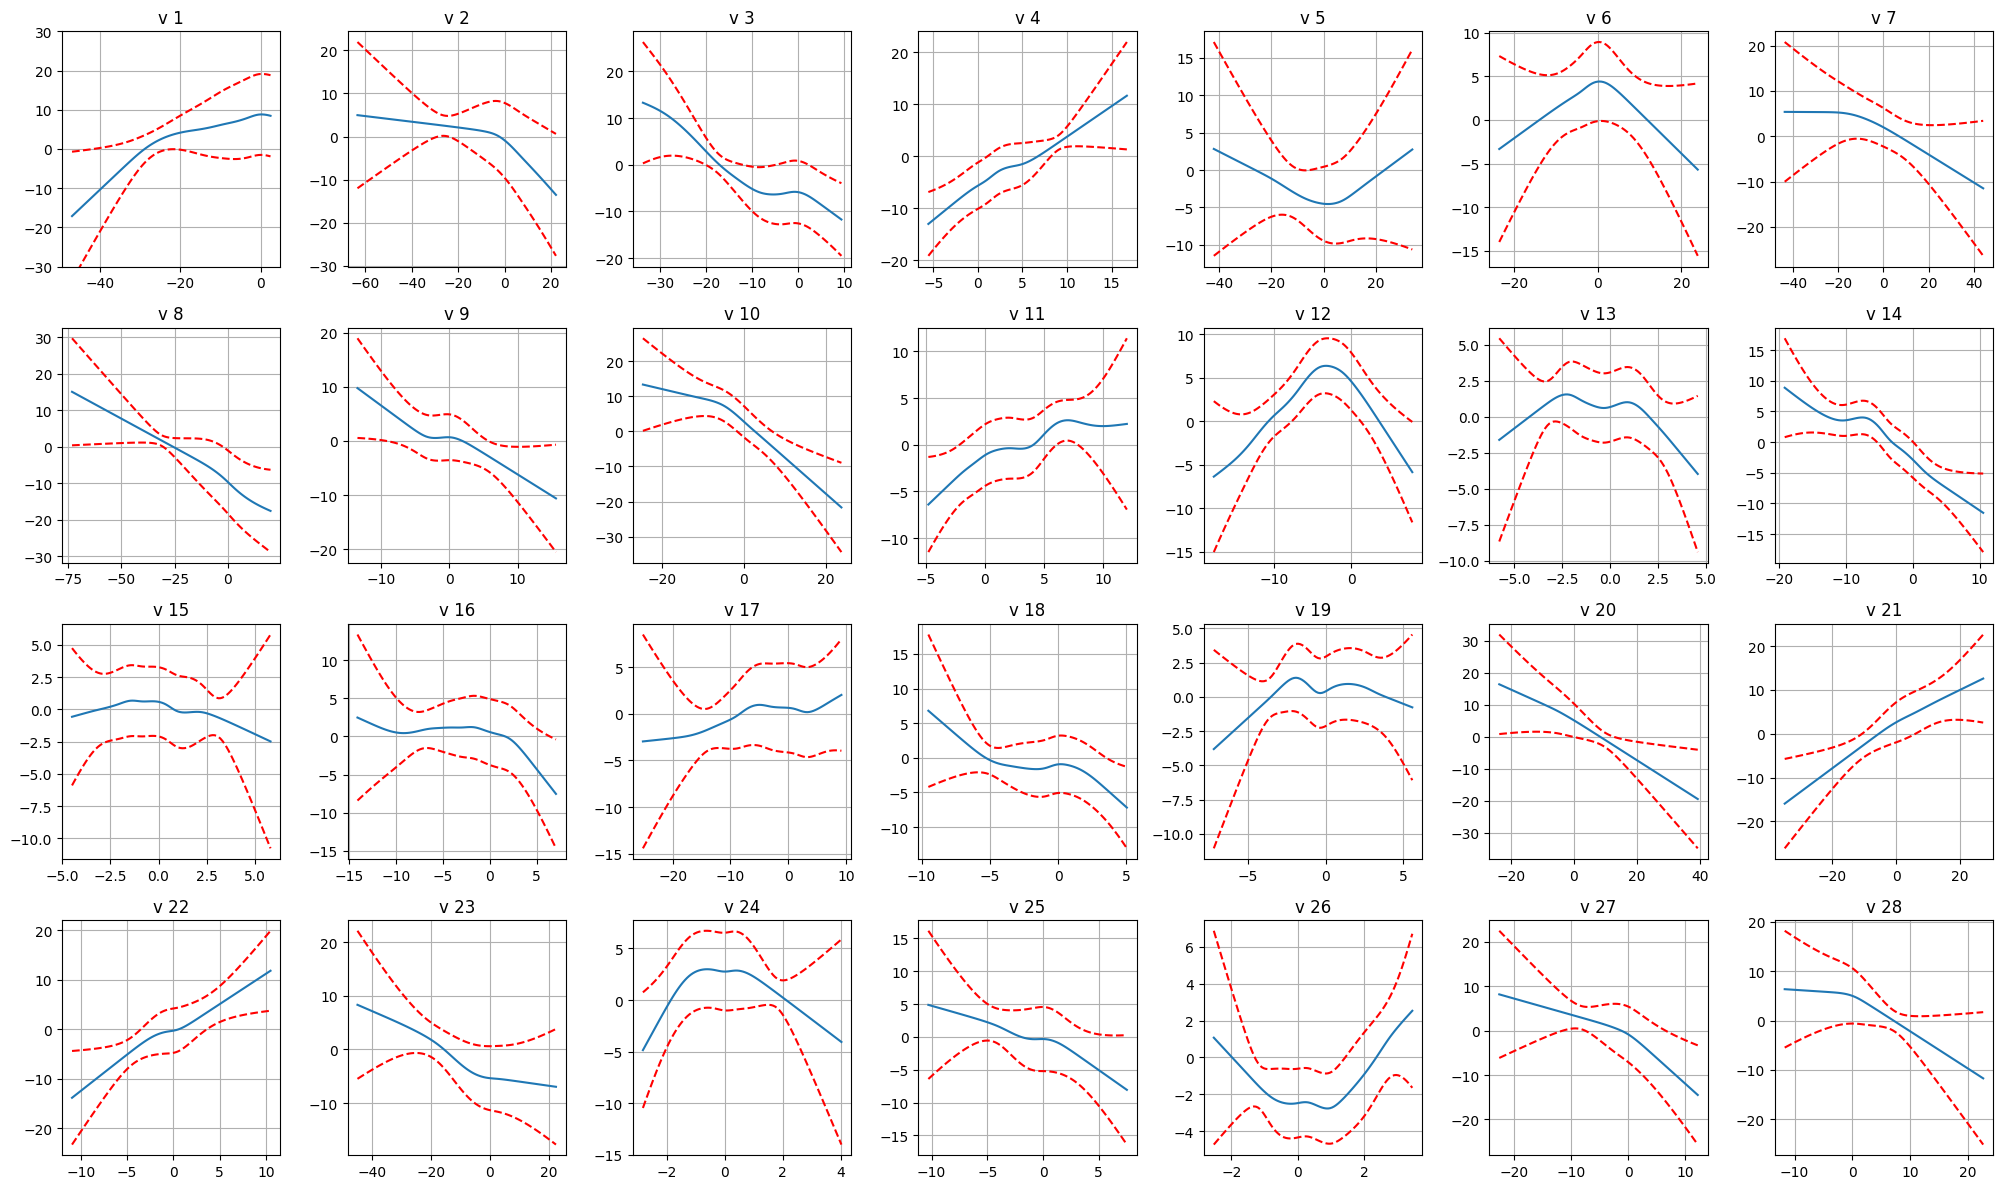

In [149]:
fig, axs = plt.subplots(4, 7, figsize=(20, 12))  # 4 rows, 7 columns

for i, ax in enumerate(axs.flat):
    XX = gam2.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam2.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam2.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    if i == 0:
        ax.set_ylim(-30,30)
    ax.set_title(f'v {i+1}')
    ax.grid()


plt.tight_layout()
plt.show()

In [150]:
gam2.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     92.9538
Link Function:                        LogitLink Log Likelihood:                                  -418.8454
Number of Samples:                       199364 AIC:                                             1023.5984
                                                AICc:                                            1023.6879
                                                UBRE:                                               2.0055
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                    0.835
Feature Function                  Lam

/tmp/ipykernel_3113/263715579.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam2.summary()


Confusion matrix, without normalization
[[85289     7]
 [   35   112]]


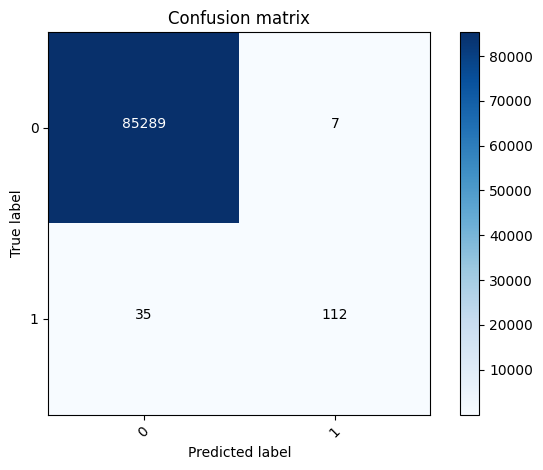

,Model,Accuracy,FalseNegRate,Recall,Precision,F1 Score
0,RandomForest,0.999497,0.244898,0.755102,0.940678,0.837736
1,DecisionTree,0.999321,0.231293,0.768707,0.824818,0.795775
2,PlainNeuralNetwork,0.999438,0.190476,0.809524,0.856115,0.832168
3,WeightedNeuralNetwork,0.976487,0.095238,0.904762,0.0625,0.116923
4,UnderSampledNN (UnderSampled test data),0.891892,0.20915,0.79085,1.0,0.883212
5,UnderSampledNN (Normal testing data),0.999438,0.204082,0.795918,0.866667,0.829787
6,OverSampledNN (OverSampled testing data),0.927904,0.142234,0.857766,0.997723,0.922466
7,OverSampledNN (Normal testing data),0.997753,0.170068,0.829932,0.422145,0.559633
8,Gam with spline + linear,0.999508,0.238095,0.761905,0.941176,0.842105
9,Gam with all spline,0.999508,0.238095,0.761905,0.941176,0.842105


In [151]:
y_pred = gam.predict(X_test)
y_expected = pd.DataFrame(y_test)
cnf_matrix = confusion_matrix(y_expected, y_pred.round())
plot_confusion_matrix(cnf_matrix, classes=[0,1])
plt.show()

acc = accuracy_score(y_test, y_pred.round())
prec = precision_score(y_test, y_pred.round())
rec = recall_score(y_test, y_pred.round())
f1 = f1_score(y_test, y_pred.round())

# Create the new DataFrame with the model results
model_result = pd.DataFrame([['Gam with all spline', acc, 1-rec, rec, prec, f1]],
                            columns=columns)

results_testset = pd.concat([results_testset, model_result], ignore_index=True)

results_testset

In [152]:
results_cv_df = pd.DataFrame(results_cv)
print(results_cv_df)

                         Model  Mean Accuracy  Std Deviation  \
0                Random Forest       0.999539       0.000038   
1                Random Forest       0.999539       0.000047   
2               Decision trees       0.999142       0.000080   
3               Neural Network       0.999308       0.000176   
4      Weighted Neural Network       0.967286       0.018623   
5  Undersampled Neural Network       0.492732       0.002308   
6   OverSampled Neural Network       0.982359       0.004291   
7     Gam with spline + linear            NaN            NaN   
8        Gams with all splines            NaN            NaN   

                             CV Scores  
0          [0.999, 1.0, 1.0, 1.0, 1.0]  
1          [0.999, 1.0, 1.0, 1.0, 1.0]  
2  [0.999, 0.999, 0.999, 0.999, 0.999]  
3  [0.999, 0.999, 0.999, 0.999, 0.999]  
4   [0.989, 0.973, 0.971, 0.97, 0.933]  
5  [0.493, 0.493, 0.493, 0.489, 0.496]  
6  [0.981, 0.985, 0.988, 0.982, 0.975]  
7            [nan, nan, nan, na